In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import roc_auc_score
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, LSTM, Masking, Input, GRU, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras import regularizers
from sklearn.utils import shuffle
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model
from qkeras.utils import model_quantize
from qkeras.utils import model_save_quantized_weights

import hls4ml

import os

import helper_functions

In [34]:
# def grumodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
#               l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
#              dense_kernel_init='lecun_uniform'):
    
#     hidden = x_in = Input(shape=(max_len, n_var,))
#     hidden = GRU(units=rec_units,
#                   recurrent_activation = rec_act,
#                   kernel_initializer = rec_kernel_init, 
#                   name = 'gru')(hidden)
    
#     hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
#     hidden = Activation('relu', name = 'relu_0')(hidden)
    
#     hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
#     hidden = Activation('relu', name = 'relu_1')(hidden)

#     hidden = Dense(3, kernel_initializer=dense_kernel_init, name = 'dense_2')(hidden)
#     hidden = Activation('softmax', name = 'output_softmax')(hidden)
    
#     model = Model(inputs=x_in, outputs=hidden)
    
#     return model

# l1_reg = 0
# l2_reg = 0

# gru_model = grumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
# gru_model.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy']) 

# gru_model.load_weights("./gru_test3/gru_floating.weights.h5", skip_mismatch=True, by_name=True) 


# print("model import")
# gru_model.summary()

# print("model")
# gru_model.summary()

# for layer in gru_model.layers:
#     weights = layer.get_weights()
#     print(layer.name, weights)

In [35]:
#gru layer
def grulayermodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
              l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
             dense_kernel_init='lecun_uniform'):
    
    hidden = x_in = Input(shape=(max_len, n_var,))
    hidden = GRU(units=rec_units,
                  recurrent_activation = rec_act,
                  kernel_initializer = rec_kernel_init, 
                  name = 'gru')(hidden)
    
    model = Model(inputs=x_in, outputs=hidden)
    
    return model

l1_reg = 0
l2_reg = 0

gru_layer_only = grulayermodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
gru_layer_only.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy']) 

gru_layer_only.load_weights("./gru_test3/gru_floating.weights.h5", skip_mismatch=True, by_name=True) 


In [36]:
def nongrumodel(max_len, n_var, rec_units, ndense=[50, 10], l1_reg=0,
              l2_reg=0, rec_act='sigmoid', extra_lab='none', rec_kernel_init='VarianceScaling',
             dense_kernel_init='lecun_uniform'):
    
    hidden = x_in = Input(shape=(max_len, n_var,))
    
    #hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
    hidden = Dense(50, kernel_initializer=dense_kernel_init, name='dense_0' )(hidden)
    hidden = Activation('relu', name = 'relu_0')(hidden)
    
    hidden = Dense(10, kernel_initializer=dense_kernel_init, name='dense_1' )(hidden)
    hidden = Activation('relu', name = 'relu_1')(hidden)

    hidden = Dense(3, kernel_initializer=dense_kernel_init, name = 'dense_2')(hidden)
    #hidden = Activation('softmax', name = 'output_softmax')(hidden)
    
    model = Model(inputs=x_in, outputs=hidden)
    
    return model

In [37]:
## nongru model
l1_reg = 0
l2_reg = 0

#nogru_model = nongrumodel(15, 6, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
nogru_model = nongrumodel(50, 120, 120, [50, 10], l1_reg=l1_reg, l2_reg=l2_reg)
nogru_model.compile(optimizer='adam', loss=['categorical_crossentropy'], metrics=['accuracy'])  

In [38]:
nogru_model.load_weights("./gru_test3/gru_floating.weights.h5", skip_mismatch=True, by_name=True) 

print("nogru model")
nogru_model.summary()

nogru model
Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 50, 120)]         0         
                                                                 
 dense_0 (Dense)             (None, 50, 50)            6050      
                                                                 
 relu_0 (Activation)         (None, 50, 50)            0         
                                                                 
 dense_1 (Dense)             (None, 50, 10)            510       
                                                                 
 relu_1 (Activation)         (None, 50, 10)            0         
                                                                 
 dense_2 (Dense)             (None, 50, 3)             33        
                                                                 
Total params: 6,593
Trainable params: 6,593
Non

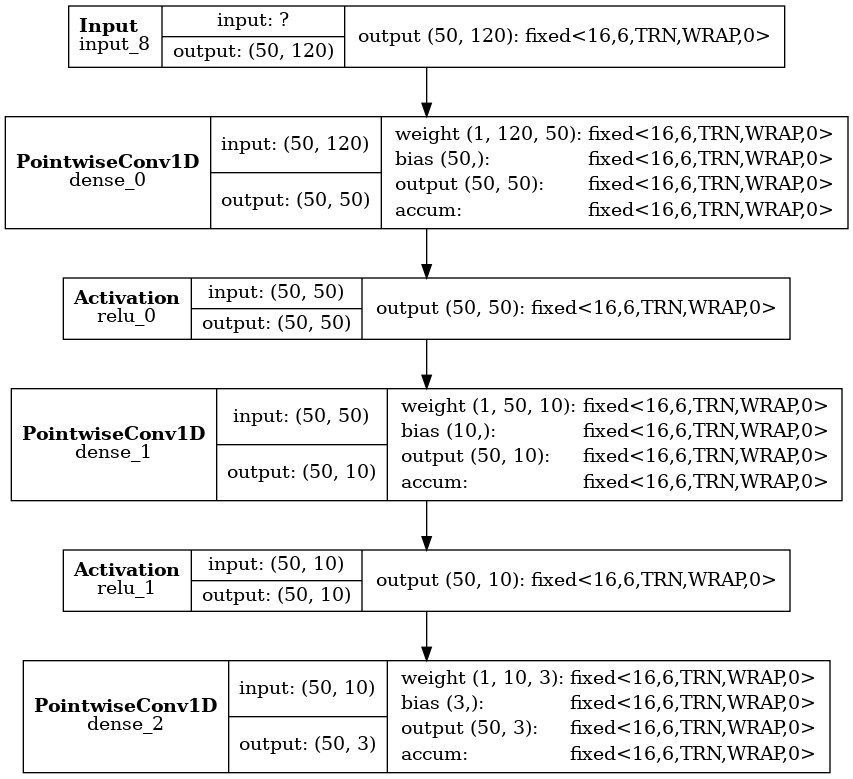

In [39]:
config = hls4ml.utils.config_from_keras_model(nogru_model, granularity='model')
#config = hls4ml.utils.config_from_keras_model(model, granularity='model')
                                # backend='Vivado' #granularity = 'name' #granularity = 'model' 
                                # default_precision='ap_fixed<16,6>' # default_reuse_factor=2
config['Model']['ReuseFactor'] = 10
config['Model']['Precision'] = 'ap_fixed<16,6>' 
config['Model']['Trace'] = True

##config['Flows'] = ['vivado:fifo_depth_optimization']
##hls4ml.model.optimizer.get_optimizer('vivado:fifo_depth_optimization').configure(profiling_fifo_depth=100_000)

output = 'gru_16_6_reuse10_bigboard_stream'

#creating hls model using 'Vivado'
backendSynth = 'Vivado' #vitis'

hls_model = hls4ml.converters.convert_from_keras_model(
    #model, 
    nogru_model,
    hls_config=config, 
    backend=backendSynth, 
    output_dir=(f'models/gru_floating_point/{output}/hls4ml_prj'), #fifoop_
    part='xcvu13p-fhga2104-3-e',
    io_type='io_stream'
) 

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)


In [40]:
hls_model.compile()

In [41]:
#X_test = np.ascontiguousarray(X_test)

#y_hls = hls_model.predict(X_test)

x_test_toptag = np.load('/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/traindata_toptag/x_test.npy')
x_test_gru_inport = np.ascontiguousarray(x_test_toptag)

x_gru_chopped = np.resize(x_test_gru_inport, (x_test_gru_inport.shape[0], 15, 6)) #x_test_gru_inport.shape[0], 

# top tag data
y_gruonly = gru_layer_only.predict(x_gru_chopped)
y_gruonly_shaped = np.resize(y_gruonly, (x_test_gru_inport.shape[0], 50, 120))
predict_nogru = hls_model.predict(y_gruonly_shaped)  
#predict_nogru = hls_model.predict(x_gru_chopped)  

# # making 0's
# x_test_gru_zeros = np.zeros((x_test_gru_inport.shape[0], 15, 6))

# # zeroed input data
# y_gruonly_zeros = gru_layer_only.predict(x_test_gru_zeros)
# y_gruonly_zeros_shaped = np.resize(y_gruonly_zeros, (x_test_gru_inport.shape[0], 50, 120))
# predict_nogru_zeroes = hls_model.predict(y_gruonly_zeros_shaped)

print (predict_nogru)

624/624 [==============================] - 2s 2ms/step
[[ 2.9433594  -1.5058594  -0.89746094 ...  1.3251953  -1.1894531
   0.6113281 ]
 [ 0.90722656 -1.1835938   1.0263672  ...  2.459961   -1.2802734
  -0.6894531 ]
 [ 2.725586   -1.453125   -0.49609375 ...  1.4248047  -1.2636719
   0.6191406 ]
 ...
 [ 1.9365234  -1.1816406  -0.17480469 ...  1.1923828  -1.1298828
   0.5341797 ]
 [ 2.428711   -1.3935547  -0.35058594 ...  2.7705078  -1.4755859
  -0.6279297 ]
 [ 1.0419922  -1.15625     0.83496094 ...  1.4101562  -1.0898438
   0.21191406]]


In [42]:
# from hls4ml.model.profiling import numerical, get_ymodel_keras
# hls4ml_pred, hls4ml_trace = hls_model.trace(y_gruonly_shaped[:1000])

# print (hls4ml_pred)
# print (hls4ml_trace)

# numerical(model=nogru_model, hls_model=hls_model, X=y_gruonly_shaped[:1000])

In [43]:
## writing the predicted outputs files, uncomment out if need to make outputs again 
os.makedirs(f'./acc/gru', exist_ok=True)

# with open(f'./acc/gru/hls_zeros.txt', 'w') as f: #_noSoft
#     #f.write(str(y_nogru_zeroes))
#     for y_nogru_zeroes_layers in predict_nogru_zeroes:
#         pos = 0
#         for y_nogru_zeroes_small in y_nogru_zeroes_layers:
#             #for y_nogru_zeroes_small in y_nogru_zeroes_individual:
#             pos += 1
#             if pos >= 3:
#                 f.write(str(y_nogru_zeroes_small))
#                 f.write("\n")
#                 pos = 0
#             else:
#                 f.write(str(y_nogru_zeroes_small)+",")
            
with open(f'./acc/no_gru/hls_noSoft_predict.txt', 'w') as f: #_noSoft
     for y_nogru_layers in predict_nogru:
        pos = 0
        for y_nogru_small in y_nogru_layers:
            #for y_nogru_small in y_nogru_individual:
            pos += 1
            if pos >= 3:
                f.write(str(y_nogru_small))   
                f.write("\n")
                pos = 0      
            else:
                f.write(str(y_nogru_small)+",")
        f.write("\n")

In [44]:
#hls_model.build(csim=False)

In [48]:
x_test_toptag = np.load('/home/quin/HLS4ML_VS_MANUAL/documents/Benchmarks/Btagging/qkeras/traindata_toptag/x_test.npy')
x_test_gru_inport = np.ascontiguousarray(x_test_toptag)

x_gru_chopped = np.resize(x_test_gru_inport, (x_test_gru_inport.shape[0], 15, 6)) #x_test_gru_inport.shape[0], 

# # top tag data
y_gruonly = gru_layer_only.predict(x_gru_chopped)
y_gruonly_shaped = np.resize(y_gruonly, (x_test_gru_inport.shape[0], 50, 120))
predict_nogru = nogru_model.predict(y_gruonly_shaped)  

with open(f'./acc/no_gru/keras_noSoft_predict.txt', 'w') as f: #_noSoft
    for y_nogru_layers in predict_nogru:
        for y_nogru_individual in y_nogru_layers:
            pos = -1
            for y_nogru_small in y_nogru_individual:
                pos += 1
                if pos == y_nogru_individual.size-1:
                    f.write(str(y_nogru_small))
                else:
                    f.write(str(y_nogru_small)+",")
            f.write("\n")

624/624 [==============================] - 1s 1ms/step
